In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('data.csv')

# Data structure

In [9]:
# Shape of the dataset, first 5 rows

print("Shape", df.shape)
df.head()

Shape (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


Total of 11500 in the dataset.

The dataset contains EEG signal recordings from 500 subjects, each lasting 23.6 seconds. Each instance in the dataset corresponds to one second of EEG signal measurements from a single subject, yielding a total of 11,500 instances (500 × 23).

A single instance in the dataset contains 178 attributes (signal values over time) and one target variable (class), located in the 179th column of the table.

#  Splitting the dataset into features and the target variable

In [10]:
# Feature and target variable split

X = df.drop(['y', 'Unnamed'], axis=1) # features (without 'Unnamed')
y = df['y'] # target

print("X shape - features -", X.shape)
print("y shape - target variable - ", y.shape)

X shape - features - (11500, 178)
y shape - target variable -  (11500,)


# Class distribution analysis

In [11]:
print(f"Number of classes in the dataset: {y.nunique()}")
print(f"Classes: {[int(x) for x in sorted(y.unique())]}")

Number of classes in the dataset: 5
Classes: [1, 2, 3, 4, 5]


The dataset contains five classes, defined according to different characteristics of the EEG signals.

Class 1 corresponds to brain activity during an epileptic seizure, while Classes 2–5 correspond to brain activity recorded in the absence of a seizure.


In [12]:
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)
y = df['y']

We reduce the problem to two classes:

- Seizure (Class 1, labeled '1'), and <br>
- Non-seizure activity (Classes 2–5, labeled '0').

Sample count by binary classes (0: No attack, 1: Attack):

   Sample count  Percentage (%)
y                              
0          9200            80.0
1          2300            20.0


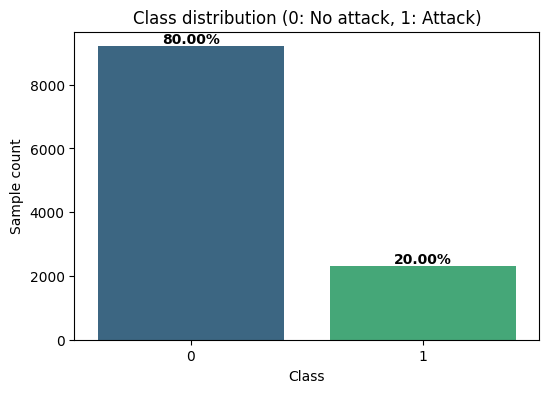

In [13]:
# Tabele and bar chart for class distribution

counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    'Sample count': counts,
    'Percentage (%)': percentages
})

print("Sample count by binary classes (0: No attack, 1: Attack):\n")

print(distribution_table)


plt.figure(figsize=(6, 4))
sns.barplot(x=distribution_table.index, y=distribution_table['Sample count'], palette='viridis', hue=distribution_table.index, legend=False)

plt.title('Class distribution (0: No attack, 1: Attack)')
plt.xlabel('Class')
plt.ylabel('Sample count')

for i, v in enumerate(counts):
    plt.text(i, v + 100, f'{percentages[i]:.2f}%', ha='center', fontweight='bold')

plt.show()

Reducing the problem to a binary classification task results in **an imbalanced dataset**, as only one of the five classes represents seizure activity.

## EEG Signal Plots by Binary Class

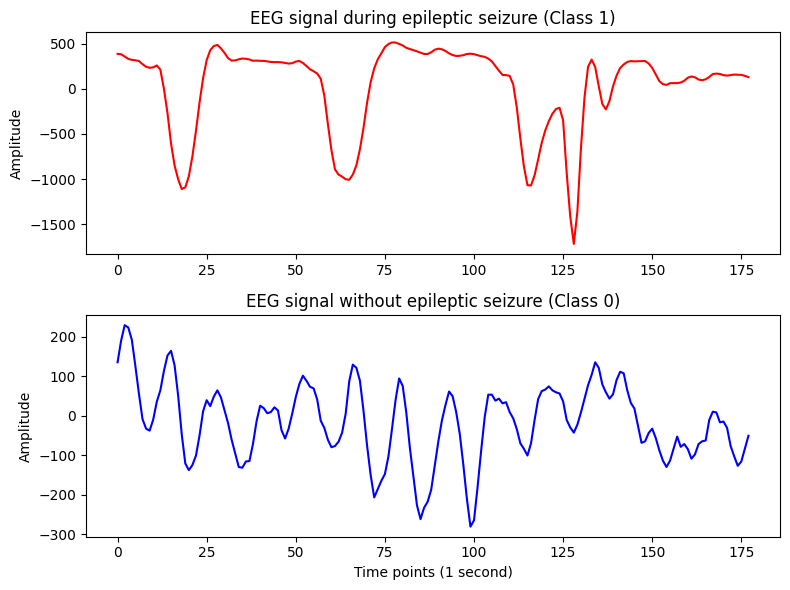

In [15]:
# EEG Signal Plot by Binary Class
# Selecting One Example for Each Binary Class

seizure = df[df['y'] == 1].iloc[0, 1:179] # First row with a seizure
no_seizure = df[df['y'] == 0].iloc[0, 1:179] # First row without a seizure

# Plotting the Signal
plt.figure(figsize=(8, 6))

# First subplot - Seizure
plt.subplot(2, 1, 1)
plt.plot(seizure.values, color='red')
plt.title('EEG signal during epileptic seizure (Class 1)')
plt.ylabel('Amplitude')

# Second subplot - No Seizure
plt.subplot(2, 1, 2)
plt.plot(no_seizure.values, color='blue')
plt.title('EEG signal without epileptic seizure (Class 0)')
plt.xlabel('Time points (1 second)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


# Statistical Analysis of Standard Deviation and Variance

### Standard Deviation of the Signal by Class

In [16]:
# std & var analysis by class
std_values = X.std(axis=1)
var_values = X.var(axis=1)

signal_stats = pd.DataFrame()
signal_stats["std"] = std_values
signal_stats["var"] = var_values
signal_stats["class"] = y

table = signal_stats.groupby("class")[["std", "var"]].agg(["mean", "median", "min", "max"])
table.columns = ["_".join(col) for col in table.columns]
table = table.round(2)

print(table)

       std_mean  std_median  std_min  std_max   var_mean  var_median  var_min  \
class                                                                           
0         51.53       44.94    10.71   541.48    3828.04     2019.25   114.77   
1        303.47      277.41    51.50   810.40  115518.15    76958.39  2651.94   

         var_max  
class             
0      293205.20  
1      656749.44  


Class '1' (seizure) shows a higher standard deviation.

# Missing Values

In [17]:
# Missing Values Analysis

print("Sum of missing values in each column:\n")
df.isna().sum()

Sum of missing values in each column:



Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

Conclusion: There are no missing values.

# Outliers

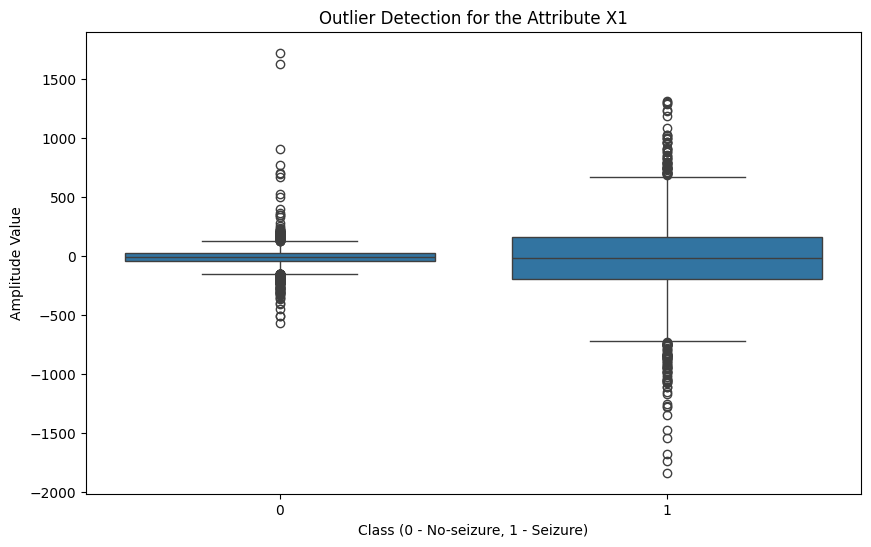

In [19]:
# Outliers

# Automatically retrieve the name of the second column (usually X1)
column_title = df.columns[1]

plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y=column_title, data=df)

plt.title(f'Outlier Detection for the Attribute {column_title}')
plt.xlabel('Class (0 - No-seizure, 1 - Seizure)')
plt.ylabel('Amplitude Value')
plt.show()


# Correlation Matrix

We select a small subset of columns (e.g., the first 15 time points), as a 178 × 178 correlation matrix would be difficult to interpret.

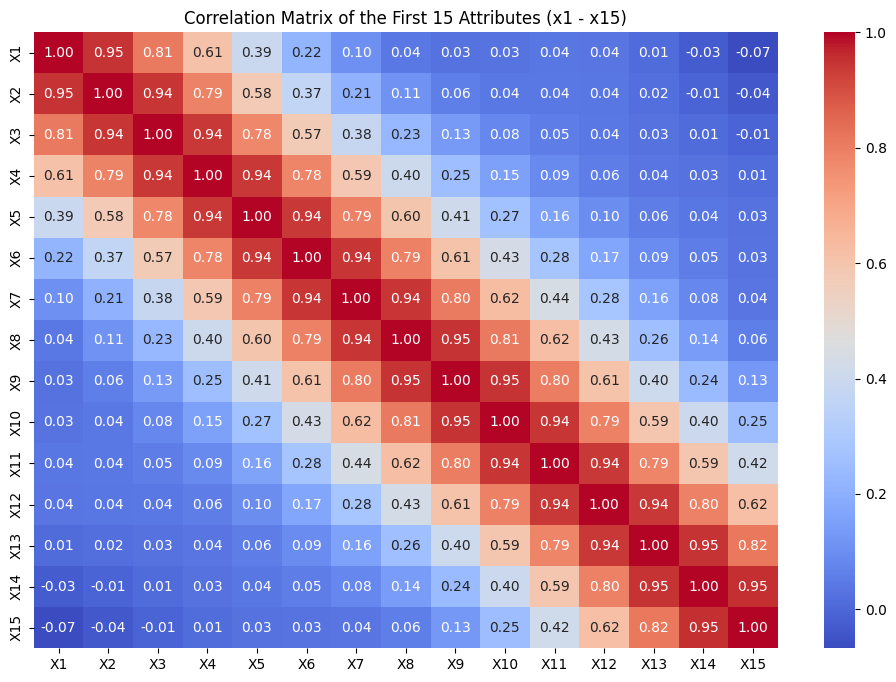

In [20]:
# Correlation Matrix

subset_columns = df.iloc[:, 1:16]

plt.figure(figsize=(12, 8))
# Calculating correlation
corr_matrix = subset_columns.corr()

# Plotting Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of the First 15 Attributes (x1 - x15)')
plt.show()

# Analysis of the 'Unnamed' Column

In [23]:

df = pd.read_csv("data.csv")
df['Unnamed'].head()

0    X21.V1.791
1    X15.V1.924
2       X8.V1.1
3     X16.V1.60
4     X20.V1.54
Name: Unnamed, dtype: str

The values in the 'Unnamed'column consist of three segments separated by periods (.).

In [24]:
# Format of the values in this column:
# X[number].V[number].[number]
# Three segments separated by '.'

parts = df['Unnamed'].str.split('.', expand=True)
parts.columns = ['part1', 'part2', 'part3']
df = pd.concat([df, parts], axis=1)

### The First Segment
Format - X[number]

In [25]:
# First segment: X[number]
df['part1'].value_counts().sort_index()

part1
X1     500
X10    500
X11    500
X12    500
X13    500
X14    500
X15    500
X16    500
X17    500
X18    500
X19    500
X2     500
X20    500
X21    500
X22    500
X23    500
X3     500
X4     500
X5     500
X6     500
X7     500
X8     500
X9     500
Name: count, dtype: int64

In [ ]:
df.groupby('part1').size().value_counts()


500    23
Name: count, dtype: int64

Interpretation of the First Segment:

X1 ... X23 represent segment identifiers.

Each subject has 23 one-second segments, and there are 500 subjects in total. Therefore, each segment identifier appears 500 times in the dataset.

### The Second Segment
Format - V[number]

In [27]:
df['part2'].value_counts().sort_index()

part2
V1     11408
V11       23
V12       23
V13       23
V14       23
Name: count, dtype: int64

In [28]:
pd.crosstab(df['part2'], df['y'])

y,1,2,3,4,5
part2,,,,,
V1,2277,2277,2277,2277,2300
V11,0,0,0,23,0
V12,0,0,23,0,0
V13,0,23,0,0,0
V14,23,0,0,0,0


Interpretation of the Second Segment:

Based on the distribution of values in the second segment, we conclude that it does not provide meaningful information.

It can be assumed that this segment originates from the file-naming or indexing scheme used within the system.


###  The Third Segment
Format - [number]

In [29]:
df['part3'].head()

0    791
1    924
2      1
3     60
4     54
Name: part3, dtype: str

In [20]:
df.groupby('part3').size()

part3
1      23
10     23
101    23
102    23
103    23
       ..
99     23
991    23
992    23
993    23
994    23
Length: 495, dtype: int64

**Interpretation of the Third Segment**

The third segment contains 495 unique values, which is close to the total number of subjects in the dataset. Each unique value appears 23 times, corresponding to the 23 one-second segments associated with a single EEG recording.

Therefore, the third segment is s an identifier for the complete EEG recording of 1 patient.



We observe that the third segment is missing in a certain portion of the dataset.

In [30]:
# Number of Rows Missing Segment 3
num_missing = df['part3'].isna().sum()

# Total Number of Rows
total_rows = len(df)

# Percentage
percent_missing = (num_missing / total_rows) * 100

print(f"Rows without the third segment: {num_missing} / {total_rows} = {percent_missing:.2f}%")

Rows without the third segment: 115 / 11500 = 1.00%


The third segment is missing in 1% of the dataset.

### Segment 3 Becomes a New Feature `recording_id`.

If we were to perform a random train/test split, data originating from the same EEG recording could end up in different subsets.
<br>
Idea: Perform the train/test split by grouping on recording_id, ensuring that data from the same recording is kept together and preventing data leakage.

In the following step, a new column named `recording_id` is created and will be used to split the data into training and test sets.

Rows that do not contain the third segment are removed.


In [32]:
df = pd.read_csv("data.csv")

def extract_parts(unnamed):
    parts = unnamed.split(".")
    # Ensure that part3 exists; otherwise, assign NaN

    part3 = int(parts[2]) if len(parts) == 3 else pd.NA
    return pd.Series({
        "part1": parts[0],   # X segment
        "part2": parts[1],   # V segment
        "part3": part3       # original recording ID
    })

df[['part1', 'part2', 'part3']] = df['Unnamed'].apply(extract_parts)

# Create a new column 'recording_id'
df['recording_id'] = df['part3']

# Processing rows where recording_id does not exist
# Removal, as their number is small (~115/11500)
df_clean = df.dropna(subset=['recording_id'])
df_clean = df_clean[df_clean['recording_id'].astype(str).str.strip() != ""]


C:\Users\ivana.horvat\AppData\Local\Temp\ipykernel_43448\4281460461.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['part1', 'part2', 'part3']] = df['Unnamed'].apply(extract_parts)
C:\Users\ivana.horvat\AppData\Local\Temp\ipykernel_43448\4281460461.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['recording_id'] = df['part3']


## Data Preparation for Training, Validation, and Test Set Splitting

In [33]:
df_clean = df_clean.drop('Unnamed', axis=1)
df_clean = df_clean.drop('part1', axis=1)
df_clean = df_clean.drop('part2', axis=1)
df_clean = df_clean.drop('part3', axis=1)

In [34]:
# Splitting into Features and the Target Variable

X = df_clean.drop('y', axis=1)
df_clean['y'] = df_clean['y'].apply(lambda x: 1 if x == 1 else 0)
y = df_clean['y']

The data includes a ``recording_id`` column to ensure that the dataset is split correctly according to EEG recordings. The ``recording_id`` column will be removed after the split.


## Train/Validation/Test Split Without Data Leakage

The dataset is split into a training set (70%), a validation set (15%), and a test set (15%).

Segments from a single EEG recording (patient) are contained exclusively within one of the subsets.

In [35]:
# Performing a Train/Test Split with GroupShuffleSplit

from sklearn.model_selection import GroupShuffleSplit

groups = df_clean['recording_id']

# First split: 70% training, 30% temporary set
# (the temporary set will later be split into validation and test sets)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_train = X_train.drop('recording_id', axis=1) # IMPORTANT: removing recording_id
y_train = y.iloc[train_idx]

X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]

groups_temp = groups.iloc[temp_idx]  # zadržavamo grupu za drugi split

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val = X_temp.iloc[val_idx]
X_val = X_val.drop('recording_id', axis=1) # IMPORTANT: removing recording_id
y_val = y_temp.iloc[val_idx]

X_test = X_temp.iloc[test_idx]
X_test = X_test.drop('recording_id', axis=1) # IMPORTANT: removing recording_id
y_test = y_temp.iloc[test_idx]

# Results
print("Number of training samples:", len(X_train))
print("Number of validation samples:", len(X_val))
print("Number of test samples:", len(X_test))


Number of training samples: 7958
Number of validation samples: 1702
Number of test samples: 1725


## Verification That Data Leakage Has Been Prevented

In [38]:
# Check for overlapping recording_id values between the training and test sets
train_groups = set(groups.iloc[train_idx])
val_groups = set(groups_temp.iloc[val_idx])
test_groups = set(groups_temp.iloc[test_idx])

print("Overlap between train and validation sets:", train_groups & val_groups)
print("Overlap between train and test sets:", train_groups & test_groups)
print("Overlap between validation and test sets:", val_groups & test_groups)

print("\nNumber of unique recording_id values in the training set:", len(train_groups))
print("Number of unique recording_id values in the validation set:", len(val_groups))
print("Number of unique recording_id values in the test set:", len(test_groups))



Overlap between train and validation sets: set()
Overlap between train and test sets: set()
Overlap between validation and test sets: set()

Number of unique recording_id values in the training set: 346
Number of unique recording_id values in the validation set: 74
Number of unique recording_id values in the test set: 75


All segments sharing the same ``recording_id`` are assigned to a single subset, and the subsets are mutually exclusive.

# Data Standardization Using the StandardScaler Function

StandardScaler works by computing the mean and standard deviation for each feature (column). This step, known as fit(), is performed only on the training dataset.
<br><br>
The scaler then uses the statistics learned from the training set to transform all three datasets (training, validation, and test) using the transform() function.
<br><br>
This approach also prevents data leakage during the standardization process, as information from the validation and test sets is not used when computing the scaling parameters.


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled.copy()
X_val = X_val_scaled.copy()
X_test = X_test_scaled.copy()

# Validation of StandardScaler Results

In [40]:
feature_columns_before_scaling = X.drop('recording_id', axis=1).columns

selected_columns_for_stats = ['X1', 'X30', 'X60']

column_indices = {
    col: feature_columns_before_scaling.get_loc(col)
    for col in selected_columns_for_stats
}

scaled_datasets = {
    'X_train_scaled': X_train_scaled,
    'X_val_scaled': X_val_scaled,
    'X_test_scaled': X_test_scaled
}

for name, data_array in scaled_datasets.items():
    print(f"\nStatistics for the {name} set")
    for col_name, idx in column_indices.items():
        mean_val = data_array[:, idx].mean()
        std_val = data_array[:, idx].std()
        print(f"  {col_name}: Mean = {mean_val:.4f}, Std = {std_val:.4f}")


Statistics for the X_train_scaled set
  X1: Mean = 0.0000, Std = 1.0000
  X30: Mean = 0.0000, Std = 1.0000
  X60: Mean = 0.0000, Std = 1.0000

Statistics for the X_val_scaled set
  X1: Mean = -0.0168, Std = 1.2165
  X30: Mean = 0.0031, Std = 1.2482
  X60: Mean = 0.0374, Std = 1.2105

Statistics for the X_test_scaled set
  X1: Mean = -0.0158, Std = 0.9057
  X30: Mean = -0.0138, Std = 1.0223
  X60: Mean = -0.0245, Std = 0.9597


The training set has a mean of 0 and a standard deviation of 1, which is expected since StandardScaler is fitted on this dataset specifically to achieve these values.

The means are close to 0 and the standard deviations are close to 1 for both the validation and test datasets.
<br><br>
The differences relative to the training set reflect natural variations in the data distributions across the different subsets.
<br><br>

These differences arise because the validation and test sets are transformed using scaling parameters learned exclusively from the training set. This ensures that data leakage is prevented during the standardization process.

In [41]:
import numpy as np
import os

os.makedirs("preprocessed", exist_ok=True)

np.save("preprocessed/X_train.npy", X_train)
np.save("preprocessed/X_val.npy",   X_val)
np.save("preprocessed/X_test.npy",  X_test)
np.save("preprocessed/y_train.npy", y_train.values)
np.save("preprocessed/y_val.npy",   y_val.values)
np.save("preprocessed/y_test.npy",  y_test.values)

print("Preprocessed splits saved to preprocessed")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

Preprocessed splits saved to preprocessed
  X_train : (7958, 178)
  X_val   : (1702, 178)
  X_test  : (1725, 178)
